# YOLOv8 Model Training and Inference Workflow

End-to-end workflow for using a YOLOv8 object detection model:

1. **Load a pretrained model**  
   - The `YOLO("yolo11n.pt")` call loads a YOLOv8-nano model with pretrained weights, ready for further training or inference.

2. **Train the model on a dataset**  
   - `model.train(...)` fine-tunes the model on the `COCO8` dataset for 100 epochs.  

3. **Evaluate model performance**  
   - `model.val()` runs validation on the dataset to calculate metrics such as precision, recall, and mAP.

4. **Run inference on a single image**  
   - `model("mountain_goat.jpeg")` performs object detection, returning predicted bounding boxes, class labels, and confidence scores.

5. **Export the trained model for deployment** (optional)  
   - `model.export(format="onnx")` converts the trained model to ONNX format, enabling deployment in other frameworks or applications.


In [ ]:
# Check that these imports are working and versions are compatible
import torch, torchvision
print(torch.__version__)
print(torchvision.__version__)


2.8.0+cu128
0.23.0+cu128


In [ ]:
# use the GPU if it's available
import torch
from ultralytics import YOLO

torch.cuda.is_available()
device = 0 if torch.cuda.is_available() else 'cpu'
print(device)

0


In [ ]:
# Load a pretrained YOLO11n model
model = YOLO("yolo11n.pt")

# Train the model on the COCO8 dataset for 100 epochs
train_results = model.train(
    data="coco8.yaml",  # Path to dataset configuration file
    epochs=100,  # Number of training epochs
    imgsz=640,  # Image size for training
    device=device,
)

# Evaluate the model's performance on the validation set
metrics = model.val()

# Perform object detection on an image
results = model("mountain_goat.jpeg")  # Predict on an image

# Replaced this display with a cell that prints it in the notebook
# results[0].show()  # Display results

# Export the model to ONNX format for deployment
# path = model.export(format="onnx")  # Returns the path to the exported model

Ultralytics 8.3.186 🚀 Python-3.11.8 torch-2.8.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4080, 15952MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco8.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pretrained=True

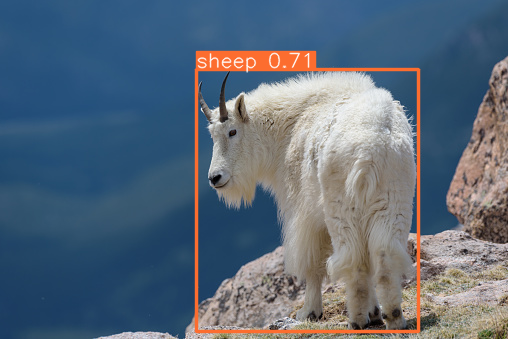

In [ ]:
# Display the test image with the bounding box
from IPython.display import display
from PIL import Image

im = results[0].plot()                    # BGR NumPy array
display(Image.fromarray(im[:, :, ::-1]))  # convert to RGB and display
